In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Overview

The dataset contains information about different cars and their fuel efficiency.

The main target variable is `mpg`, which represents miles per gallon.

For this project, `horsepower` is selected as the independent variable and `mpg` is selected as the dependent variable.

In [33]:
df = pd.read_csv('/content/auto-mpg.csv')

In [34]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [35]:
df.duplicated().sum()


np.int64(0)

### Missing Value Analysis

Initially, missing values were checked using `isnull().sum()`.

The `horsepower` column contained missing/non-numeric values, so it was converted into numeric format using `pd.to_numeric()` with `errors='coerce'`.

The resulting missing values were removed before model building.

In [36]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [38]:
# Safe conversion: turns text errors into NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

### Data Type Analysis

The data types of all features were checked using `df.dtypes`.

Since `horsepower` is used as the input feature for regression, it must be numeric.

Therefore, non-numeric values were converted to `NaN` and subsequently removed.

In [39]:
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


### Statistical Summary

The `describe()` function was used to understand the distribution of numerical variables.

It provides important statistics such as:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

These statistics help us understand the scale and spread of the data before applying regression.

In [40]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [52]:
df['horsepower'].isna().sum()

np.int64(6)

In [54]:
df = df.dropna(subset=['horsepower'])

In [55]:
print(df['horsepower'].isna().sum())

0


### Relationship Between Horsepower and MPG

The scatter plot shows the relationship between `horsepower` and `mpg`.

A general negative relationship can be observed: as horsepower increases, MPG tends to decrease.

However, the relationship is not perfectly linear. The data points show some curvature, which makes Polynomial Regression worth investigating.

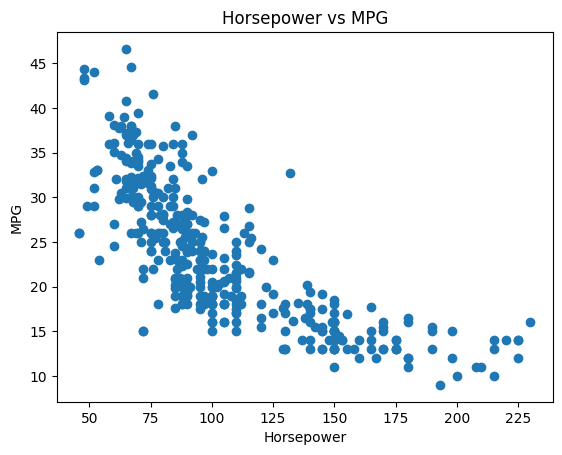

In [14]:
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')
plt.show()

### Outlier Analysis

A boxplot was used to identify potential outliers in the `horsepower` feature.

Using the IQR method, 10 observations were identified as potential outliers.

These observations have relatively high horsepower values.

Since high horsepower can represent legitimate high-performance vehicles, the observations were not automatically removed. They will be retained unless further analysis indicates that they are data errors.

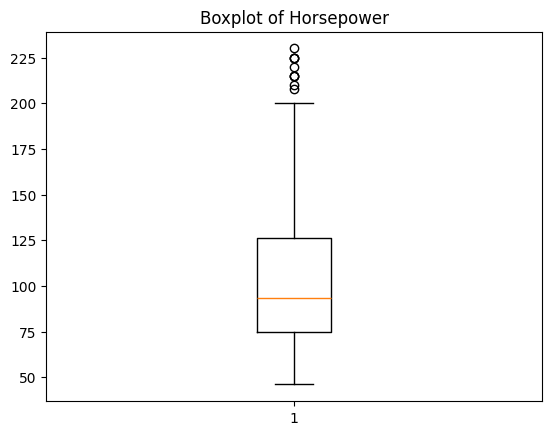

In [56]:
plt.boxplot(df['horsepower'])
plt.title('Boxplot of Horsepower')
plt.show()

In [57]:
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['horsepower'] < lower) |
    (df['horsepower'] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

Lower limit: -1.5
Upper limit: 202.5
Number of outliers: 10


### MPG Outlier Analysis

The IQR method was also applied to the target variable `mpg`.

This helps identify unusually low or high fuel-efficiency observations.

Outliers were analyzed rather than automatically removed because an extreme MPG value can represent a genuine vehicle characteristic.

In [58]:
Q1 = df['mpg'].quantile(0.25)
Q3 = df['mpg'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mpg_outliers = df[
    (df['mpg'] < lower) |
    (df['mpg'] > upper)
]

print("MPG lower:", lower)
print("MPG upper:", upper)
print("MPG outliers:", len(mpg_outliers))

MPG lower: -1.0
MPG upper: 47.0
MPG outliers: 0


## EDA Conclusion

From the exploratory analysis:

1. `mpg` is selected as the target variable.
2. `horsepower` is selected as the independent variable.
3. Non-numeric values in `horsepower` were converted to missing values and handled.
4. The relationship between horsepower and MPG shows a negative trend.
5. The relationship does not appear perfectly linear, providing motivation to test Polynomial Regression.
6. Potential outliers were identified using the IQR method.
7. The identified outliers were retained because they may represent legitimate observations rather than data errors.

Based on these findings, Linear Regression will first be used as a baseline model, followed by Polynomial Regression to determine whether a nonlinear relationship provides a better fit.

In [130]:
df.to_csv("processed_data.csv", index=False)

In [59]:
X = df[['horsepower']]
y = df['mpg']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
lr= LinearRegression()

In [63]:
lr.fit(X_train, y_train)

LinearRegression()

In [64]:
print("Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficient: [-0.16259724]
Intercept: 40.606097600118346


In [65]:
y_pred = lr.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3.782512710126959
MSE : 22.153237123863413
RMSE: 4.706722545876633
R²  : 0.5659681822256185


The scatter plot shows a negative relationship between horsepower and MPG.

As horsepower increases, MPG generally decreases.

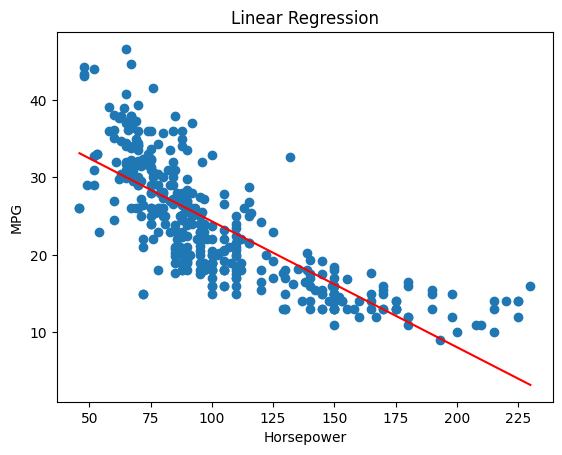

In [122]:
plt.scatter(X, y)
plt.plot(X_line, y_line , color='r')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression")

plt.show()

In [68]:
from sklearn.preprocessing import PolynomialFeatures

In [114]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [115]:
from sklearn.linear_model import LinearRegression

poly_lr = LinearRegression()

In [116]:
poly_lr.fit(X_train_poly, y_train)

LinearRegression()

In [117]:
y_pred_poly = poly_lr.predict(X_test_poly)

In [118]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
MAE : 3.2446826726586067
MSE : 18.460267222145088
RMSE: 4.296541309256212
R²  : 0.6383217814069444


The curve shows the relationship between horsepower and MPG.

It captures the nonlinear relationship between the two variables.

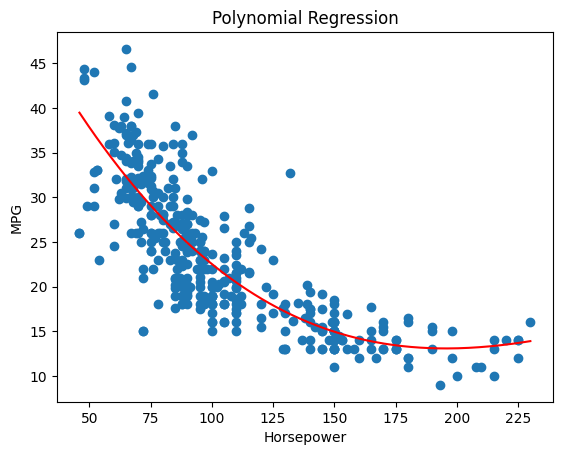

In [123]:
plt.scatter(X, y)
plt.plot(X_curve, y_curve , color='r')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression")

plt.show()

### Save Model

The trained model is saved using Joblib so it can be reused later without training again.

In [124]:
pip install joblib

In [129]:
import joblib
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("poly", poly),
    ("regression", poly_lr)
])

joblib.dump(model, "polynomial_regression_model.pkl")

['polynomial_regression_model.pkl']